<a href="https://colab.research.google.com/github/jelaenas/CESISTA-KJ-DSC1105/blob/main/CESISTA_SA_1_DSC1105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
install.packages(c("tidyverse","moments","robustbase","MASS","lattice","lm.beta"))

library(tidyverse)
library(moments)
library(robustbase)
library(MASS)
library(lattice)
library(lm.beta)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# Unit 1: Univariate Data Analysis
1. **Load** the dataset and summarize its structure.

In [7]:
ecommerce <- read.csv("EDA_Ecommerce_Assessment.csv")

str(ecommerce)
summary(ecommerce)

colSums(is.na(ecommerce))

'data.frame':	3000 obs. of  10 variables:
 $ Customer_ID       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Gender            : chr  "Male" "Female" "Male" "Male" ...
 $ Age               : int  65 19 23 45 46 43 42 29 22 51 ...
 $ Browsing_Time     : num  46.5 98.8 79.5 95.8 33.4 ...
 $ Purchase_Amount   : num  231.8 472.8 338.4 37.1 235.5 ...
 $ Number_of_Items   : int  6 8 1 7 3 9 6 5 8 8 ...
 $ Discount_Applied  : int  17 15 28 43 10 5 2 13 1 31 ...
 $ Total_Transactions: int  16 43 31 27 33 29 8 33 41 19 ...
 $ Category          : chr  "Clothing" "Books" "Electronics" "Home & Kitchen" ...
 $ Satisfaction_Score: int  2 4 1 5 3 2 1 3 4 5 ...


  Customer_ID        Gender               Age        Browsing_Time   
 Min.   :   1.0   Length:3000        Min.   :18.00   Min.   :  1.00  
 1st Qu.: 750.8   Class :character   1st Qu.:31.00   1st Qu.: 29.98  
 Median :1500.5   Mode  :character   Median :44.00   Median : 59.16  
 Mean   :1500.5                      Mean   :43.61   Mean   : 59.87  
 3rd Qu.:2250.2                      3rd Qu.:57.00   3rd Qu.: 89.33  
 Max.   :3000.0                      Max.   :69.00   Max.   :119.95  
 Purchase_Amount  Number_of_Items Discount_Applied Total_Transactions
 Min.   :  5.03   Min.   :1.00    Min.   : 0.00    Min.   : 1.00     
 1st Qu.:128.69   1st Qu.:3.00    1st Qu.:12.00    1st Qu.:12.00     
 Median :245.09   Median :5.00    Median :24.00    Median :24.00     
 Mean   :247.96   Mean   :4.99    Mean   :24.34    Mean   :24.68     
 3rd Qu.:367.20   3rd Qu.:7.00    3rd Qu.:37.00    3rd Qu.:37.00     
 Max.   :499.61   Max.   :9.00    Max.   :49.00    Max.   :49.00     
   Category         

Customer_ID             Gender                Age      Browsing_Time 
                 0                  0                  0                  0 
   Purchase_Amount    Number_of_Items   Discount_Applied Total_Transactions 
                 0                  0                  0                  0 
          Category Satisfaction_Score 
                 0                  0

2. **Create histograms and boxplots to visualize the distribution of Purchase_Amount, Number_of_Items, and Satisfaction_Score.**

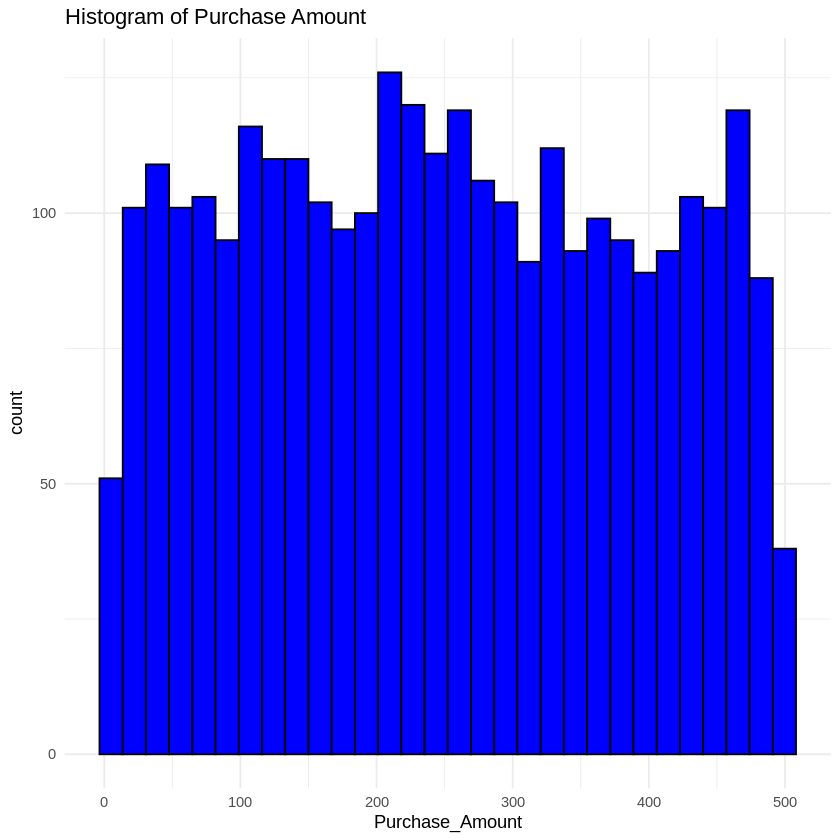

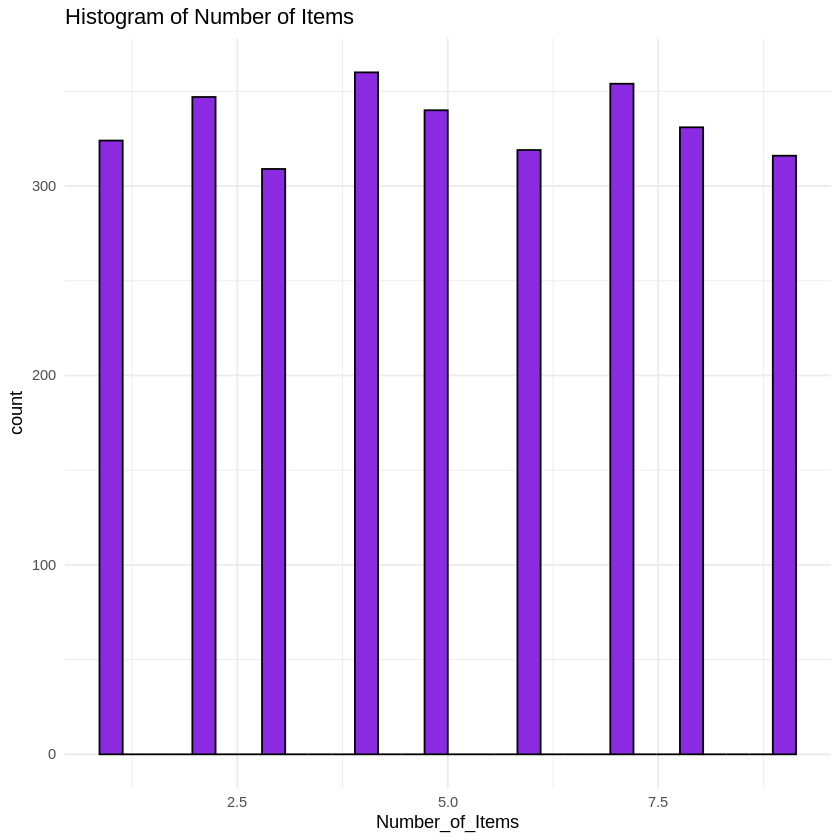

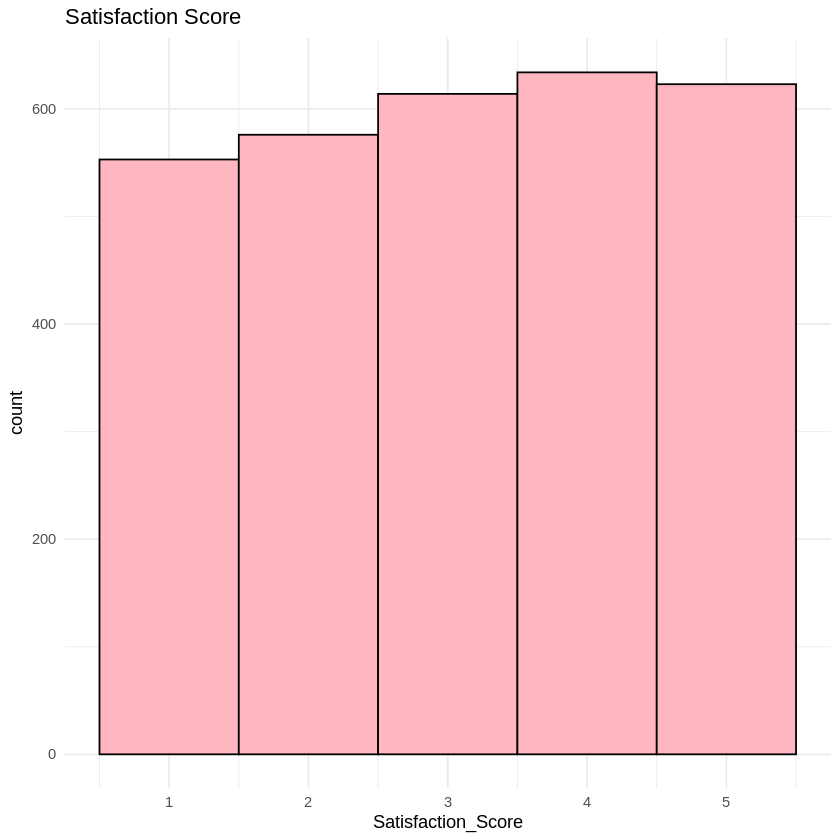

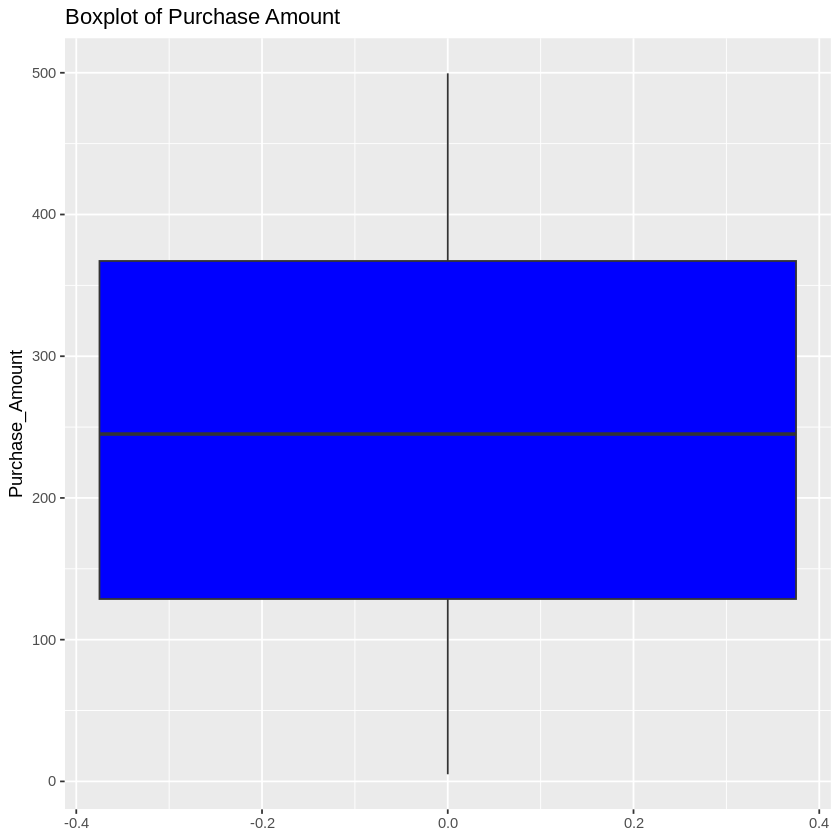

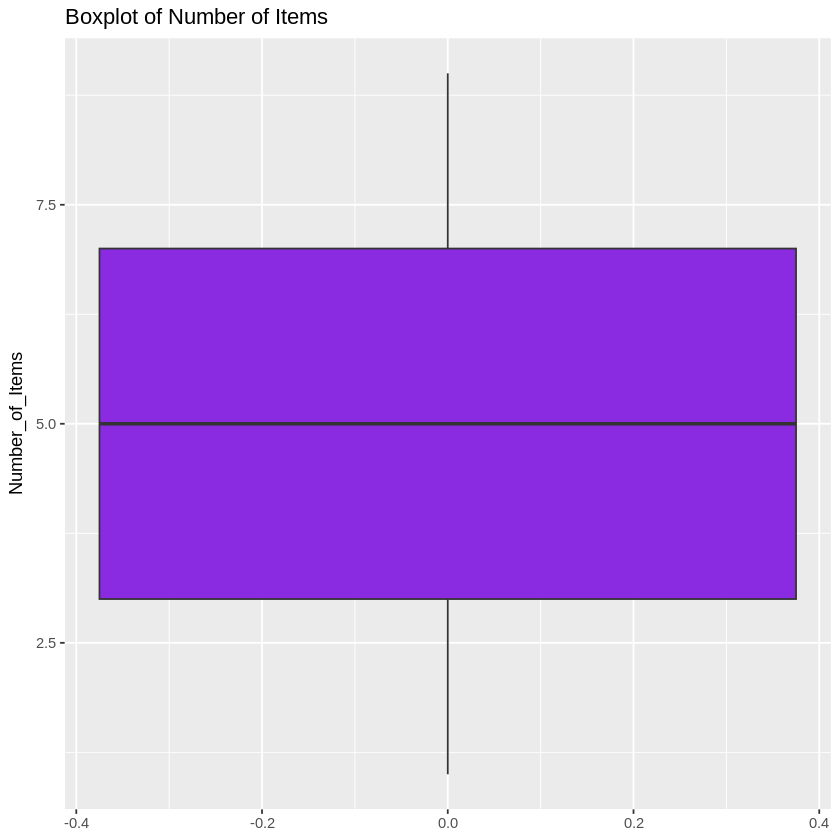

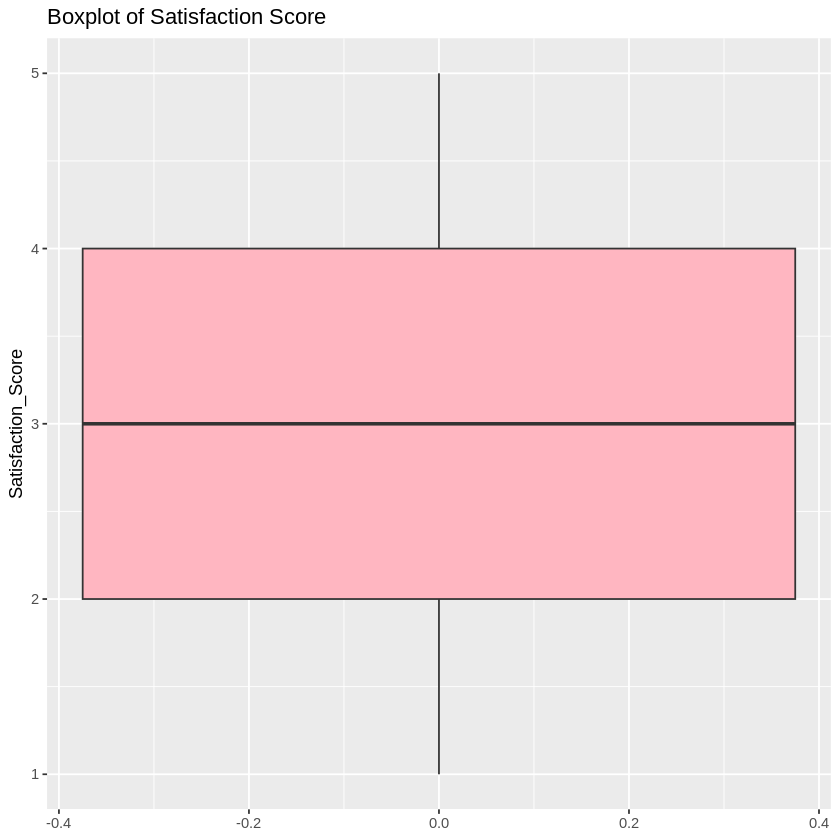

In [36]:
ggplot(ecommerce, aes(x = Purchase_Amount)) +
  geom_histogram(bins = 30, fill = "blue", color = "black") +
  labs(title = "Histogram of Purchase Amount") +
  theme_minimal()

ggplot(ecommerce, aes(x = Number_of_Items)) +
  geom_histogram(bins = 30, fill = "blueviolet", color = "black") +
  labs(title = "Histogram of Number of Items") +
  theme_minimal()

ggplot(ecommerce, aes(x = Satisfaction_Score)) +
  geom_histogram(bins = 5, fill = "lightpink", color = "black") +
  labs(title = "Satisfaction Score") +
  theme_minimal()

ggplot(ecommerce, aes(y = Purchase_Amount)) +
  geom_boxplot(fill="blue") +
  labs(title = "Boxplot of Purchase Amount")

ggplot(ecommerce, aes(y = Number_of_Items)) +
  geom_boxplot(fill="blueviolet") +
  labs(title = "Boxplot of Number of Items")

ggplot(ecommerce, aes(y = Satisfaction_Score)) +
  geom_boxplot(fill="lightpink") +
  labs(title = "Boxplot of Satisfaction Score")

3. **Compute measures of central tendency (mean, median, mode) and spread (variance, standard deviation, IQR) for Purchase_Amount.**

In [38]:
mean_purchaseamount <- mean(ecommerce$Purchase_Amount, na.rm=TRUE)
cat("Mean:", mean_purchaseamount, "\n")

median_purchaseamount <- median(ecommerce$Purchase_Amount, na.rm=TRUE)
cat("Median:", median_purchaseamount, "\n")

mode_function <- function(x){
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

mode_purchaseamount <- mode_function(ecommerce$Purchase_Amount)
cat("Mode:", mode_purchaseamount, "\n")

var_purchaseamount <- var(ecommerce$Purchase_Amount, na.rm=TRUE)
cat("Variance:", var_purchaseamount, "\n")

sd_purchaseamount <- sd(ecommerce$Purchase_Amount, na.rm=TRUE)
cat("Standard dDviation:", sd_purchaseamount, "\n")

iqr_purchaseamount <- IQR(ecommerce$Purchase_Amount, na.rm=TRUE)
cat("IQR:", iqr_purchaseamount, "\n")


Mean: 247.9625 
Median: 245.09 
Mode: 29.33 
Variance: 19845.99 
Standard dDviation: 140.8758 
IQR: 238.505 


4. **Compare the distribution of Browsing_Time and Purchase_Amount across different Gender groups using density plots.**

Based on the density plots, for both Browsing_Time and Purchase_Amount, the genders are nearly overlapping. This just means that gender does not have much of an influence on either Browsing_Time or Purchase_Amount.

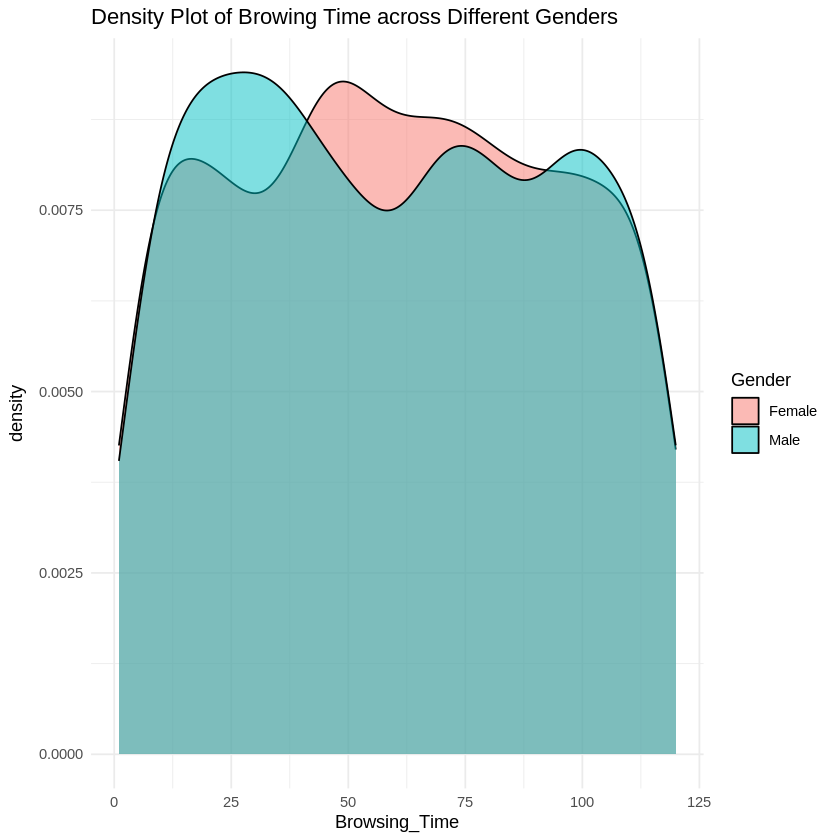

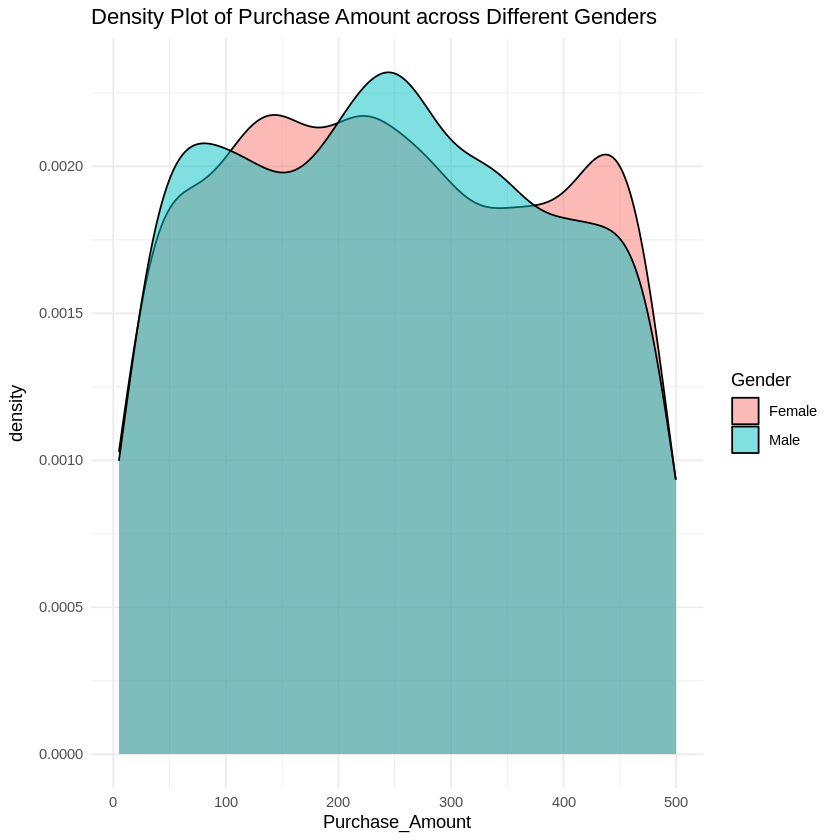

In [39]:
ggplot(ecommerce, aes(x=Browsing_Time, fill=Gender)) +
  geom_density(alpha=0.5) +
  labs(title = "Density Plot of Browing Time across Different Genders") +
  theme_minimal()

ggplot(ecommerce, aes(x=Purchase_Amount, fill=Gender)) +
  geom_density(alpha=0.5) +
  labs(title = "Density Plot of Purchase Amount across Different Genders") +
  theme_minimal()

5. **Apply a logarithmic or square root transformation on Browsing_Time and evaluate changes in skewness.**

In the original skewness of Browsing Time (0.0386349), it is close to 0 meaning it is symmetrical and has little skew. Applying a log transformation on Browsing Time (-1.364966) caused it to have strong negative skew (left-tail), this happened since original was already symmetric. While applying a square root transformation on Browsing_Time (-0.4770736), causes it to have a slight negative tail, since it is less extreme than log. This shows that applying either transformation on Browsing_Time is unnescessary. This can also be seen in the graphs.

Skewness of Browsing_Time: 0.0386349 
Skewness of log(Browsing_Time): -1.364966 
Skewness of sqrt(Browsing_Time): -0.4770736 


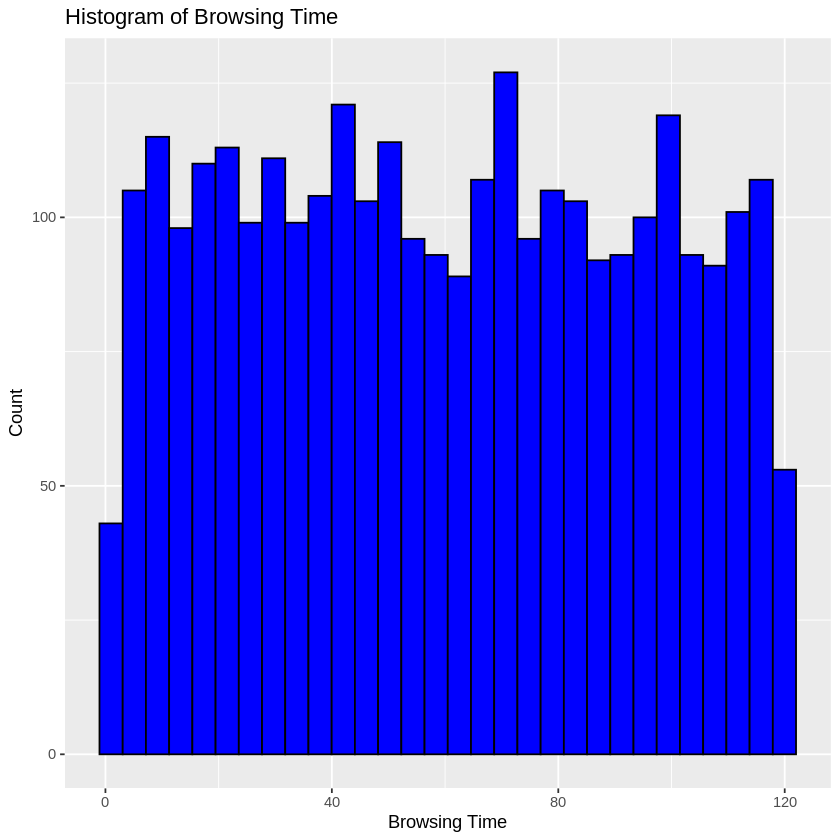

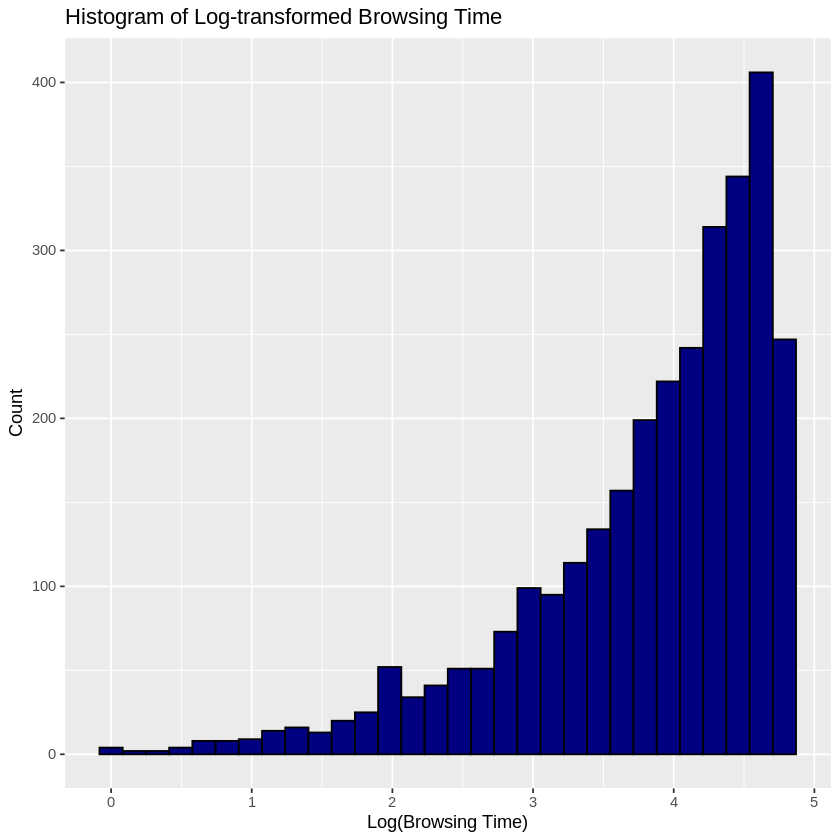

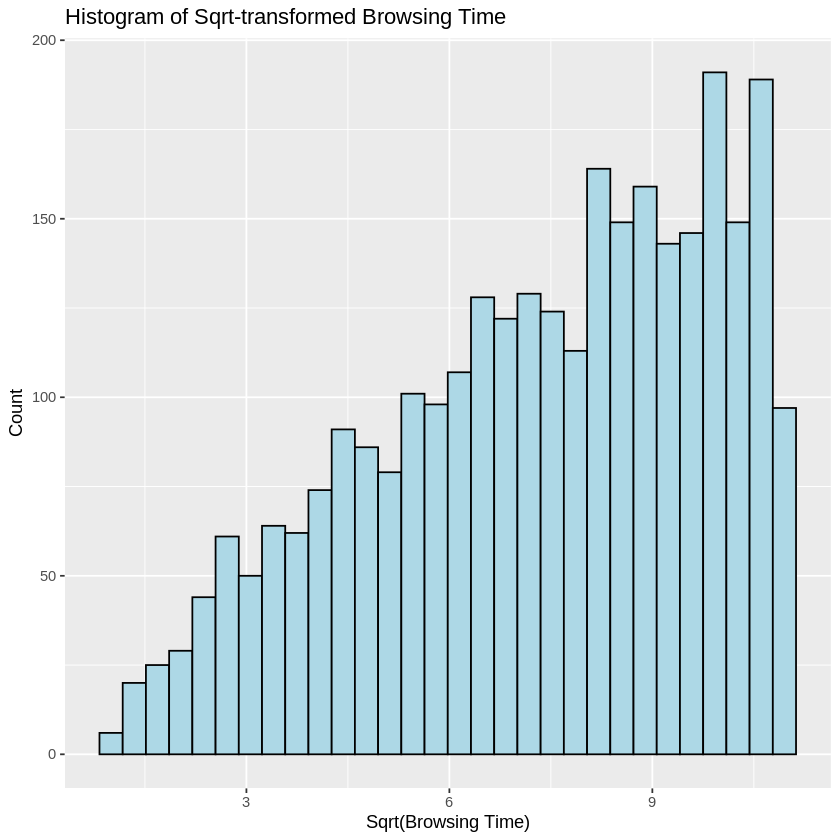

In [63]:
skew_browsing <- skewness(ecommerce$Browsing_Time)
cat("Skewness of Browsing_Time:", skew_browsing, "\n")

skew_log_browsing <- skewness(log(ecommerce$Browsing_Time))
cat("Skewness of log(Browsing_Time):", skew_log_browsing, "\n")

skew_sqrt_browsing <- skewness(sqrt(ecommerce$Browsing_Time))
cat("Skewness of sqrt(Browsing_Time):", skew_sqrt_browsing, "\n")

ecommerce$log_Browsing <- log(ecommerce$Browsing_Time)
ecommerce$sqrt_Browsing <- sqrt(ecommerce$Browsing)

# Browsing_Time
ggplot(ecommerce, aes(x = Browsing_Time)) +
  geom_histogram(bins = 30, fill = "blue", color = "black") +
  labs(title = "Histogram of Browsing Time", x = "Browsing Time", y = "Count")

# Log Browsing_Time
ggplot(ecommerce, aes(x = log_Browsing)) +
  geom_histogram(bins = 30, fill = "navyblue", color = "black") +
  labs(title = "Histogram of Log-transformed Browsing Time", x = "Log(Browsing Time)", y = "Count")

# Sqrt Browsing Time
ggplot(ecommerce, aes(x = sqrt_Browsing)) +
  geom_histogram(bins = 30, fill = "lightblue", color = "black") +
  labs(title = "Histogram of Sqrt-transformed Browsing Time", x = "Sqrt(Browsing Time)", y = "Count")

6. **Fit a simple linear regression model predicting Purchase_Amount based on Browsing_Time. Interpret the results.**

Model Equation:
Purchase_Amount = 252.65596 - 0.07839Browsing_Time

Intercept = 252.65596 which means Purchase_Amount is 252.65596 when Browsing_Time is 0.

Slope is -0.07839 meaning for every unit increase of Browsing_Time, Purchase_Amount decreases by 0.07839. This shows that Browsing_Time has little negative effect on Purchase_Amount.

t-value for Browsing_Time: -1.045 and p-value: 0.296 > 0.05 means that the slope is not statistically significant, thus there is no evidence that Browsing_Time has a meaningful effect on Purchase_Amount.

R-squared is 3.075e-05 meaning Browsing_Time only explains 0.003075% of variation of Purchasing_amount which is nearly nothing.

In [47]:
model <- lm(Purchase_Amount ~ Browsing_Time, data=ecommerce)

cat("=== Simple Linear Model ===\n")
summary(model)

=== Simple Linear Model ===



Call:
lm(formula = Purchase_Amount ~ Browsing_Time, data = ecommerce)

Residuals:
     Min       1Q   Median       3Q      Max 
-244.867 -120.473   -2.946  118.246  254.069 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   252.65596    5.17524  48.820   <2e-16 ***
Browsing_Time  -0.07839    0.07501  -1.045    0.296    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2998 degrees of freedom
Multiple R-squared:  0.0003642,	Adjusted R-squared:  3.075e-05 
F-statistic: 1.092 on 1 and 2998 DF,  p-value: 0.2961


7. **Use ggplot2 (or equivalent) to create scatter plots and regression lines.**

`geom_smooth()` using formula = 'y ~ x'


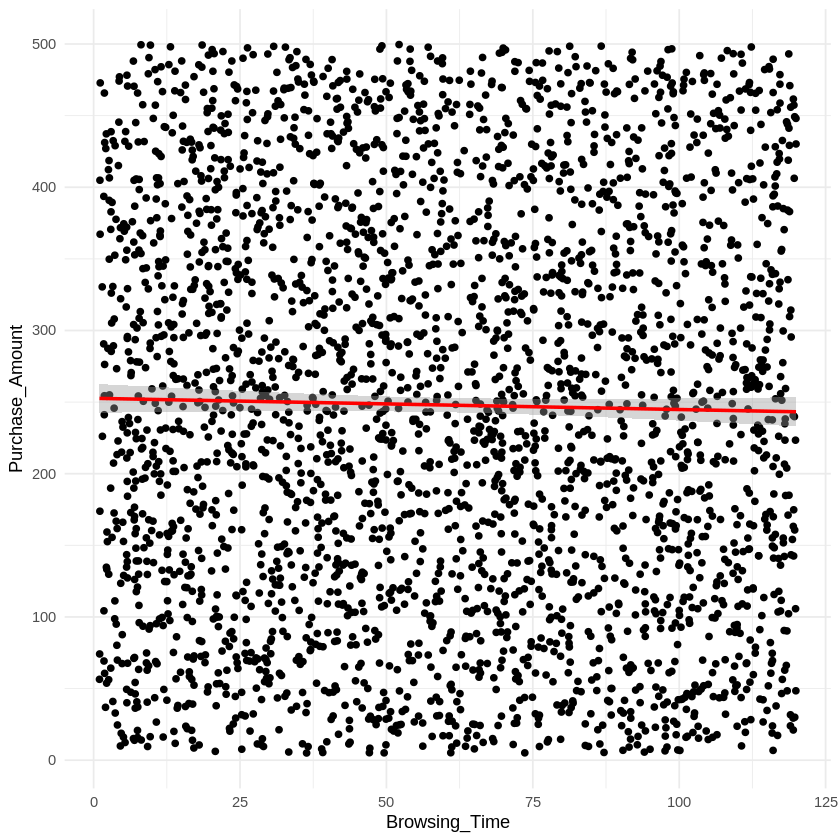

In [18]:
ggplot(ecommerce, aes(x=Browsing_Time, y=Purchase_Amount)) +
  geom_point() +
  geom_smooth(method="lm", color="red") +
  theme_minimal()

# Unit 2: Bivariate Data Analysis
8. **Create scatter plots to explore the relationship between Purchase_Amount and Number_of_Items.**

Based on the scatterplot, there appears to be no relationship between Purchase_Amount and Number_of_Items. Also shown by the blue reference line, which is horizontal.

`geom_smooth()` using formula = 'y ~ x'


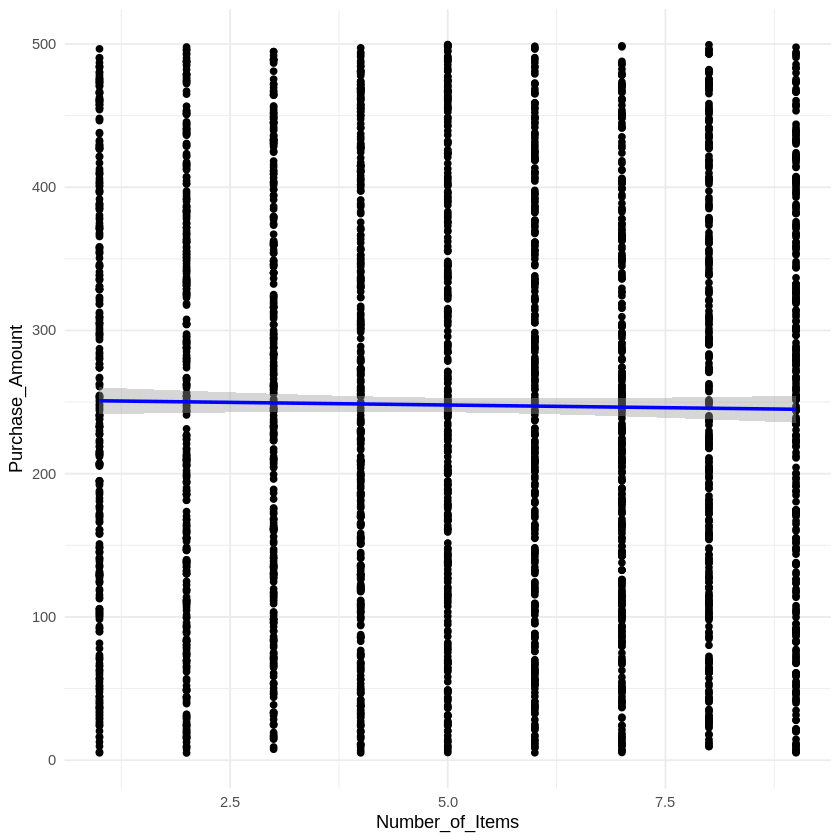

In [19]:
ggplot(ecommerce, aes(x=Number_of_Items, y=Purchase_Amount)) +
  geom_point() +
  geom_smooth(method="lm", color="blue") +
  theme_minimal()

9. **Fit a polynomial regression model for Purchase_Amount and Browsing_Time and compare it with a simple linear model.**

The polynomial model did not improve fit.There was barely any increase in multiple R-squared from 0.036% to 0.044%. Also, the adjusted R-squared decreases slightly in the polynomial model (-0.0225%) when compared to the linear model. Lastly, since p-value  0.5154 > 0.05 of the polynomial model, this means there is no statistically significant relationship between the time a customer spends browsing and the amount they spend.

Overall, adding a quadratic term did not enhance the model, proving that the relationship between Browsing_Time and Purchase_Amount is nearly non-existent.

In [48]:
model_poly <- lm(Purchase_Amount ~ poly(Browsing_Time,2), data=ecommerce)

cat("=== Simple Linear Model ===\n")
summary(model)

cat("=== Polynomial Regression Mode ===\n")
summary(model_poly)

=== Simple Linear Model ===



Call:
lm(formula = Purchase_Amount ~ Browsing_Time, data = ecommerce)

Residuals:
     Min       1Q   Median       3Q      Max 
-244.867 -120.473   -2.946  118.246  254.069 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   252.65596    5.17524  48.820   <2e-16 ***
Browsing_Time  -0.07839    0.07501  -1.045    0.296    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2998 degrees of freedom
Multiple R-squared:  0.0003642,	Adjusted R-squared:  3.075e-05 
F-statistic: 1.092 on 1 and 2998 DF,  p-value: 0.2961


=== Polynomial Regression Mode ===



Call:
lm(formula = Purchase_Amount ~ poly(Browsing_Time, 2), data = ecommerce)

Residuals:
    Min      1Q  Median      3Q     Max 
-245.47 -120.41   -3.49  118.25  255.85 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)              247.963      2.572  96.397   <2e-16 ***
poly(Browsing_Time, 2)1 -147.227    140.892  -1.045    0.296    
poly(Browsing_Time, 2)2  -68.129    140.892  -0.484    0.629    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2997 degrees of freedom
Multiple R-squared:  0.0004422,	Adjusted R-squared:  -0.0002249 
F-statistic: 0.6629 on 2 and 2997 DF,  p-value: 0.5154


10. **Apply LOESS (Locally Estimated Scatterplot Smoothing) to Purchase_Amount vs. Browsing_Time and visualize the results.**

The smoothing curve still remains almost flat which further proves that Purchase_Amount vs. Browsing_Time do not have a linear relationship.

`geom_smooth()` using formula = 'y ~ x'


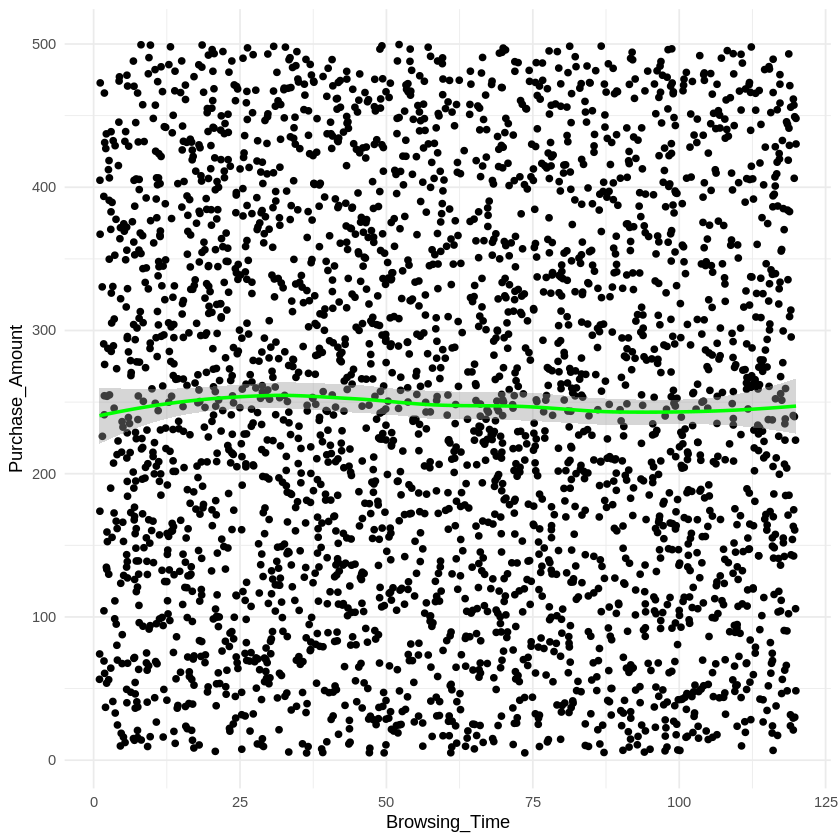

In [24]:
ggplot(ecommerce, aes(x=Browsing_Time, y=Purchase_Amount)) +
  geom_point() +
  geom_smooth(method="loess", color="green") +
  theme_minimal()

11. **Compare robust regression methods (Huber or Tukey regression) with ordinary least squares (OLS).**

The slope estimates for Browsing_Time are all small and negative (OLS: -0.078, Huber: -0.080, Tukey: -0.088), showing that none are statistically significant, which indicates that it does not have an effect. This shows that robust methods produce coefficients and fitted values similar to OLS, and all models show once again that Browsing_Time has virtually no impact on Purchase_Amount.

=== OLS Regression ===



Call:
lm(formula = Purchase_Amount ~ Browsing_Time, data = ecommerce)

Residuals:
     Min       1Q   Median       3Q      Max 
-244.867 -120.473   -2.946  118.246  254.069 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   252.65596    5.17524  48.820   <2e-16 ***
Browsing_Time  -0.07839    0.07501  -1.045    0.296    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2998 degrees of freedom
Multiple R-squared:  0.0003642,	Adjusted R-squared:  3.075e-05 
F-statistic: 1.092 on 1 and 2998 DF,  p-value: 0.2961



=== Huber Robust Regression ===



Call: rlm(formula = Purchase_Amount ~ Browsing_Time, data = ecommerce, 
    psi = psi.huber)
Residuals:
     Min       1Q   Median       3Q      Max 
-244.818 -120.331   -2.848  118.291  254.289 

Coefficients:
              Value    Std. Error t value 
(Intercept)   252.6462   5.3363    47.3448
Browsing_Time  -0.0803   0.0773    -1.0378

Residual standard error: 176.9 on 2998 degrees of freedom


=== Tukey Robust Regression ===



Call: rlm(formula = Purchase_Amount ~ Browsing_Time, data = ecommerce, 
    psi = psi.bisquare)
Residuals:
     Min       1Q   Median       3Q      Max 
-244.823 -119.866   -2.644  118.511  255.023 

Coefficients:
              Value    Std. Error t value 
(Intercept)   252.8187   5.5699    45.3899
Browsing_Time  -0.0883   0.0807    -1.0942

Residual standard error: 176.8 on 2998 degrees of freedom

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


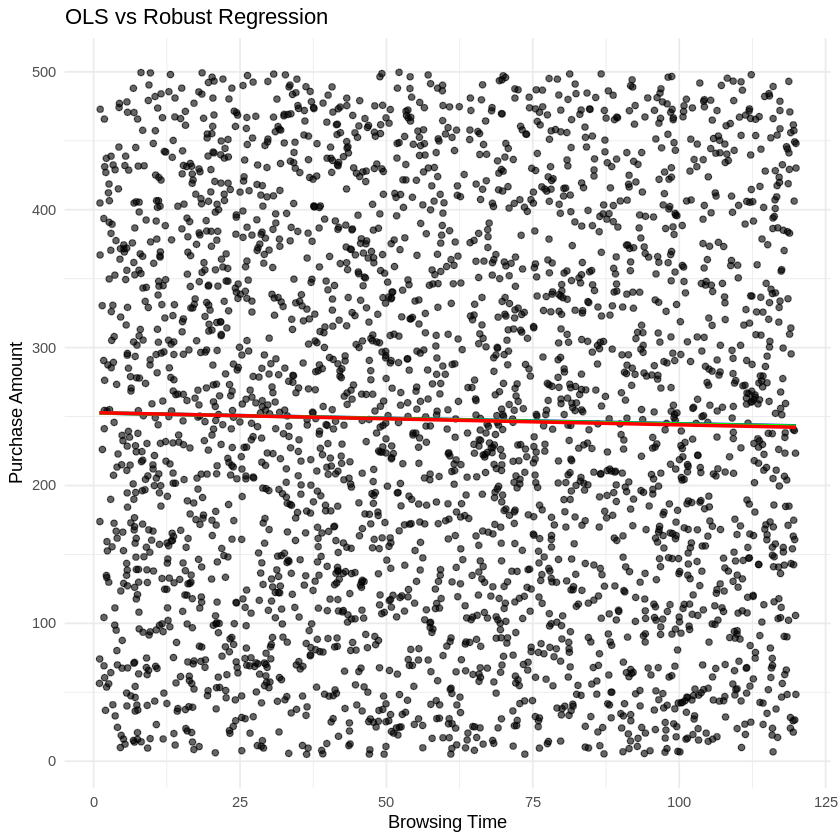

In [46]:
model_ols <- lm(Purchase_Amount ~ Browsing_Time, data = ecommerce)
model_huber <- rlm(Purchase_Amount ~ Browsing_Time, data = ecommerce, psi = psi.huber)
model_tukey <- rlm(Purchase_Amount ~ Browsing_Time, data = ecommerce, psi = psi.bisquare)

cat("=== OLS Regression ===\n")
summary(model_ols)

cat("\n=== Huber Robust Regression ===\n")
summary(model_huber)

cat("\n=== Tukey Robust Regression ===\n")
summary(model_tukey)


ggplot(ecommerce, aes(x = Browsing_Time, y = Purchase_Amount)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = FALSE, color = "blue", linetype = "solid") +
  geom_smooth(method = "rlm", se = FALSE, color = "green", linetype = "solid",
              method.args = list(psi = psi.huber)) +
  geom_smooth(method = "rlm", se = FALSE, color = "red", linetype = "solid",
              method.args = list(psi = psi.bisquare)) +
  labs(title = "OLS vs Robust Regression",
       x = "Browsing Time",
       y = "Purchase Amount") +
  theme_minimal()

# Unit 3: Trivariate/Hypervariate Data Analysis
12. **Explore interaction effects between Browsing_Time and Category on Purchase_Amount using interaction plots.**

Interaction model:
Purchase_Amount = Browsing_Time * Category

Most of the coefficients are not statistically significant and R² = 0.002844 meaning Browsing_Time + Category only explains 0.2844% of Purchase_Amount variance. Also p-value = 0.4823 > 0.05 showing that Browsing_Time + Category do not have a significant effect on Purchase_Amount.

This shows that Product category did not improve the relationship between browsing time and purchase amount, thus browsing behavior has minimal predictive power across categories.


=== Interaction Model ===



Call:
lm(formula = Purchase_Amount ~ Browsing_Time * Category, data = ecommerce)

Residuals:
     Min       1Q   Median       3Q      Max 
-257.318 -120.029   -3.757  118.013  260.157 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          248.29545   12.03041  20.639   <2e-16 ***
Browsing_Time                          0.03666    0.17024   0.215   0.8295    
CategoryBooks                         26.12580   16.60389   1.573   0.1157    
CategoryClothing                      -6.29820   16.74895  -0.376   0.7069    
CategoryElectronics                    0.68038   16.63848   0.041   0.9674    
CategoryHome & Kitchen                 1.42780   16.50719   0.086   0.9311    
Browsing_Time:CategoryBooks           -0.42094    0.23947  -1.758   0.0789 .  
Browsing_Time:CategoryClothing         0.08401    0.23746   0.354   0.7235    
Browsing_Time:CategoryElectronics     -0.08599    0.23820  -0.361   0.7181    
Browsing_

`geom_smooth()` using formula = 'y ~ x'


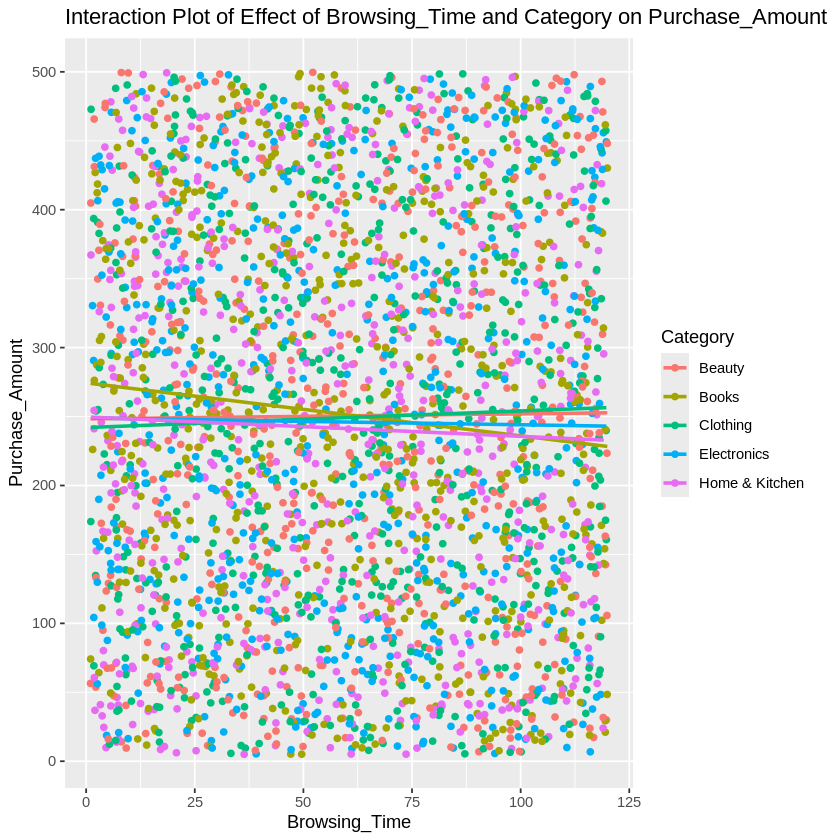

In [49]:
interaction_model <- lm(Purchase_Amount ~ Browsing_Time * Category, data=ecommerce)

cat("\n=== Interaction Model ===\n")
summary(interaction_model)

ggplot(ecommerce, aes(x=Browsing_Time, y=Purchase_Amount, color=Category)) +
  geom_point() +
  geom_smooth(method="lm", se=FALSE) +
  labs(title = "Interaction Plot of Effect of Browsing_Time and Category on Purchase_Amount")

13. **Create coplots of Purchase_Amount against Browsing_Time for different levels of Category.**

For the five plots shown, the scatter patterns are widely different and the red lines are all close to being horizontal. This means that Browsing_Time and Purchase_Amount have a weak relationship across all product categories.

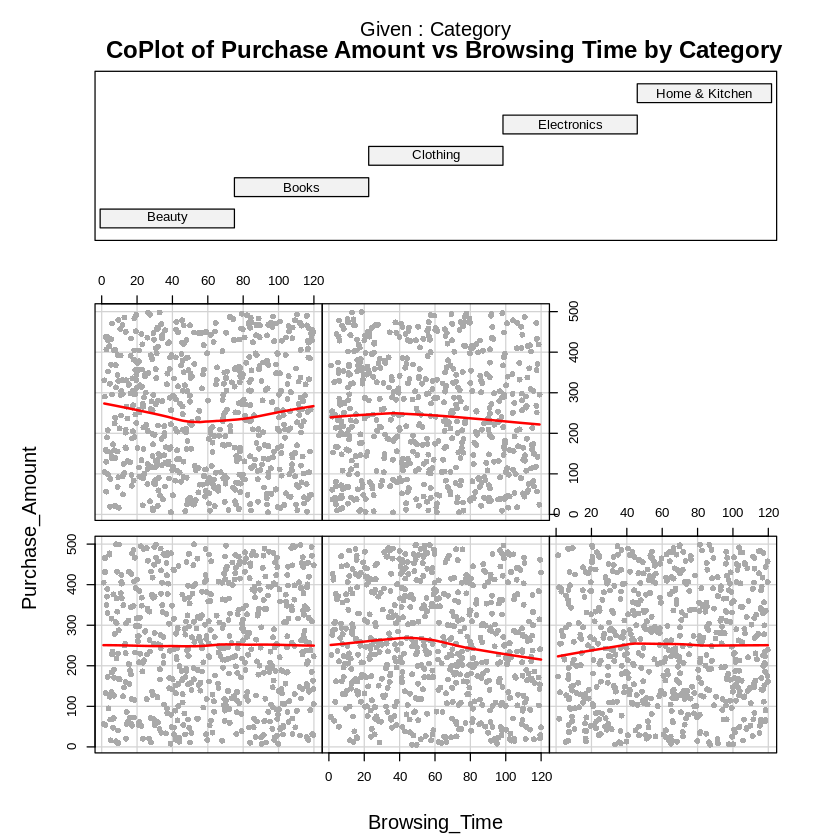

In [58]:
coplot(Purchase_Amount ~ Browsing_Time | Category, data=ecommerce,
       panel = function(x, y, ...) {
         points(x, y, pch = 16, col = "darkgray"
         lines(lowess(x, y), col = "red", lwd = 2)
       },)

title(main = "CoPlot of Purchase Amount vs Browsing Time by Category")

14. **Use level plots or contour plots to visualize relationships between Browsing_Time, Number_of_Items, and Purchase_Amount.**

There is no clear pattern which again shows that purchase amounts vary widely
and that browsing time and number of items have no clear combined effect on purchase amounts.

Warning message:
“The following aesthetics were dropped during statistical transformation: z.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


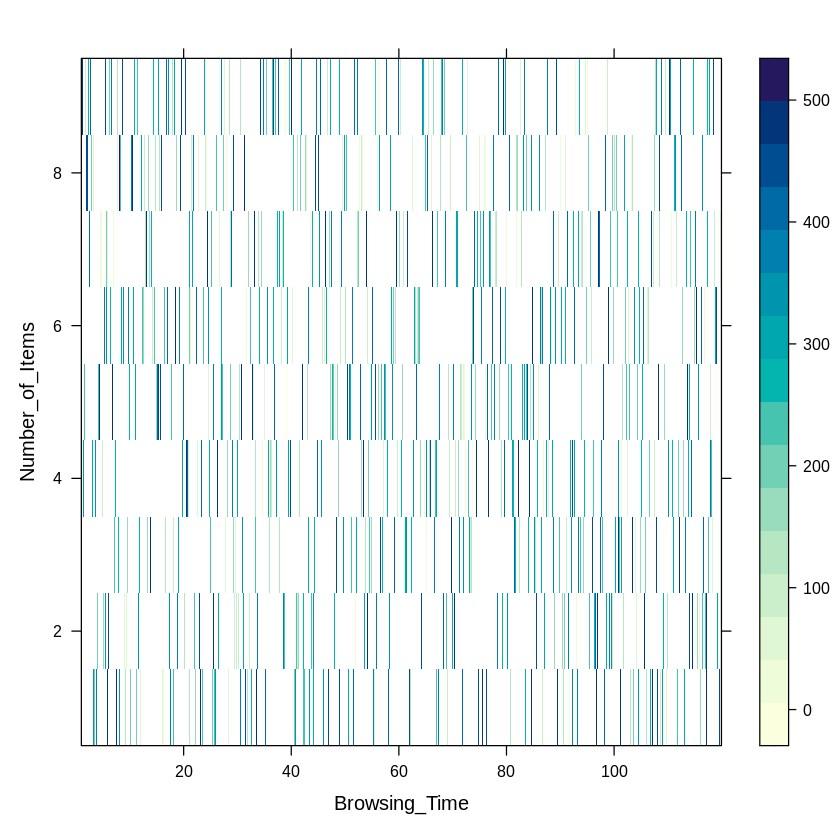

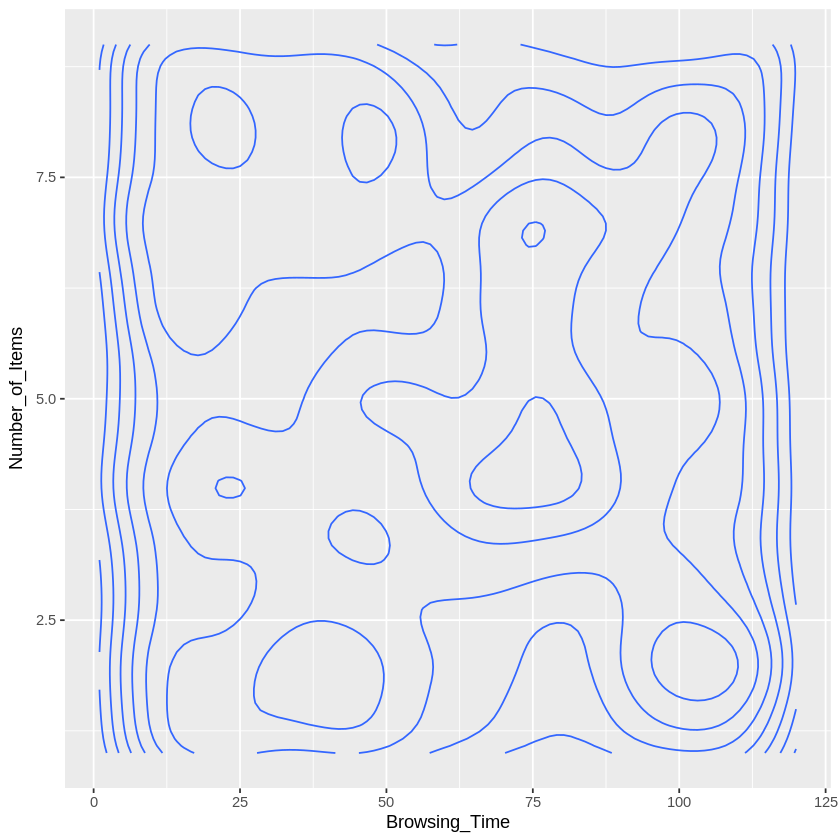

In [31]:
levelplot(Purchase_Amount ~ Browsing_Time * Number_of_Items, data=ecommerce)

ggplot(ecommerce, aes(x=Browsing_Time, y=Number_of_Items, z=Purchase_Amount)) +
  geom_density_2d()

15. **Perform multiple regression with Purchase_Amount as the dependent variable and Browsing_Time, Number_of_Items, and Satisfaction_Score as predictors. Perform model selection and assess variable importance.**

Purchase_Amount = Intercept + X1Browsing_Time + X2Number_of_Items + X3Satisfaction_Score

The multiple regression model showed that none of the slopes are statistically significant (Browsing_Time = -0.07954,  Number_of_Items = -0.78321 and Satisfaction_Score = -1.53871). Also R² = 0.0007932 meaning only 0.07% of Purchase_Amount variance is explained by Browsing_Time, Number_of_Items, and Satisfaction_Score. Lastly, p-value = 0.4978 > 0.05 further showing that there is no statistically significant relationship.

The best model was the itercept only model which is Purchase_Amount = 247.963, and the variable importance was Browsing_Time = -0.01936166, Number_of_Items = -0.01423912, and Satisfaction_Score = -0.01532117, all of which are close to zero. This shows that none of the predcitors meaningfully explain purchase amount.

In [59]:
multi_model <- lm(Purchase_Amount ~ Browsing_Time + Number_of_Items + Satisfaction_Score, data=ecommerce)
cat("=== Multiple Regression Model ===\n")
summary(multi_model)


step_model <- step(multi_model)
cat("=== Model Selection ===\n")
summary(step_model)

cat("=== Variable Importance ===\n")
lm.beta(multi_model)

=== Multiple Regression Model ===



Call:
lm(formula = Purchase_Amount ~ Browsing_Time + Number_of_Items + 
    Satisfaction_Score, data = ecommerce)

Residuals:
     Min       1Q   Median       3Q      Max 
-250.668 -120.856   -2.846  118.899  255.664 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        261.34993    9.24929  28.256   <2e-16 ***
Browsing_Time       -0.07954    0.07504  -1.060    0.289    
Number_of_Items     -0.78321    1.00497  -0.779    0.436    
Satisfaction_Score  -1.53871    1.83444  -0.839    0.402    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2996 degrees of freedom
Multiple R-squared:  0.0007932,	Adjusted R-squared:  -0.0002073 
F-statistic: 0.7928 on 3 and 2996 DF,  p-value: 0.4978


Start:  AIC=29691.89
Purchase_Amount ~ Browsing_Time + Number_of_Items + Satisfaction_Score

                     Df Sum of Sq      RSS   AIC
- Number_of_Items     1     12056 59482958 29690
- Satisfaction_Score  1     13966 59484867 29691
- Browsing_Time       1     22299 59493201 29691
<none>                            59470902 29692

Step:  AIC=29690.5
Purchase_Amount ~ Browsing_Time + Satisfaction_Score

                     Df Sum of Sq      RSS   AIC
- Satisfaction_Score  1     13479 59496437 29689
- Browsing_Time       1     21541 59504498 29690
<none>                            59482958 29690

Step:  AIC=29689.18
Purchase_Amount ~ Browsing_Time

                Df Sum of Sq      RSS   AIC
- Browsing_Time  1     21676 59518113 29688
<none>                       59496437 29689

Step:  AIC=29688.27
Purchase_Amount ~ 1

=== Model Selection ===



Call:
lm(formula = Purchase_Amount ~ 1, data = ecommerce)

Residuals:
     Min       1Q   Median       3Q      Max 
-242.933 -119.268   -2.873  119.237  251.647 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  247.963      2.572   96.41   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2999 degrees of freedom


=== Variable Importance ===



Call:
lm(formula = Purchase_Amount ~ Browsing_Time + Number_of_Items + 
    Satisfaction_Score, data = ecommerce)

Standardized Coefficients::
       (Intercept)      Browsing_Time    Number_of_Items Satisfaction_Score 
                NA        -0.01936166        -0.01423912        -0.01532117 
